# Data Cleaning Notebook

## Import Libraries and Load Merged Data

In [1]:
import pandas as pd
import numpy as np

menu_data       = pd.read_excel('../data/raw/Menu_20260411_anonymized.xlsx')
statistics_dataa = pd.read_excel('../data/raw/Statistics_per_day_20260410_anonymized.xlsx')

In [2]:
common = set(menu_data['id'].astype(str)) & set(statistics_dataa['id'].astype(str))

print("common names:", len(common))
print(list(common)[:10])

common names: 62
['52', '8', '45', '31', '26', '15', '54', '59', '16', '11']


## Menu Data

In [3]:
menu_data.head()

,meal,quantity,date,meal_type_id,name,email,id
0,كاس حليب,1,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1
1,مادلين,2,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1
2,كرواسون,1,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1
3,فيطاجي,1,2023-11-05 00:00:00,2,ANON_16ed62abf995,11,1
4,عدس,200 غرام,2023-11-05 00:00:00,2,ANON_16ed62abf995,11,1


### Handle Missing Values

In [4]:
# Check for missing values
missing_values = menu_data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
meal                0
quantity        35699
date                0
meal_type_id        0
name                0
email               0
id                  0
dtype: int64


In [5]:
# print unique values in quantity column
print("Unique values in 'quantity' column:")
print(menu_data['quantity'].unique())

Unique values in 'quantity' column:
['1' '2' '200 غرام' ... 'لحم قطع 150غ + بطاطا مقلية 100غ'
 'حمص 200 + بطاطا مقلية 100غ' 'لحم قطع 150غ + بطاطا 100غ']


In [6]:
# drop quantity column , lot of missing values, and not relevant for our analysis
menu_data.drop(columns=['quantity'], inplace=True)

In [7]:
# check for missing values again
missing_values_after = menu_data.isnull().sum()
print("Missing values after dropping 'quantity' column:")
print(missing_values_after)

Missing values after dropping 'quantity' column:
meal            0
date            0
meal_type_id    0
name            0
email           0
id              0
dtype: int64


## Handle Duplicates

In [8]:
# check for duplicates
duplicates = menu_data.duplicated().sum()
print(f"Number of duplicate rows in menu_data: {duplicates}")

Number of duplicate rows in menu_data: 6078


In [9]:
# print 2 duplicated rows example
print("Example of duplicated rows:")
menu_data[menu_data.duplicated()].head(2)

Example of duplicated rows:


,meal,date,meal_type_id,name,email,id
9,كاس حليب,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1
10,كرواسون,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1


those are acually not duplicates, they are different menu items with same name, so we will keep them as is.

In [10]:
duplicates_meal_name = menu_data.duplicated(subset=['meal', 'name', 'date', 'meal_type_id']).sum()
print(f"Number of duplicate rows based on 'meal' and 'name': {duplicates_meal_name}")

Number of duplicate rows based on 'meal' and 'name': 6078


In [11]:
# print 2 duplicated rows example based on meal and name
print("Example of duplicated rows based on 'meal' and 'name':")
menu_data[menu_data.duplicated(subset=['meal', 'name', 'date', 'meal_type_id'])].head(2)

Example of duplicated rows based on 'meal' and 'name':


,meal,date,meal_type_id,name,email,id
9,كاس حليب,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1
10,كرواسون,2023-11-05 00:00:00,1,ANON_16ed62abf995,11,1


In [12]:
# check equality of each column in the 2 duplicated rows
row1 = menu_data[menu_data.duplicated(subset=['meal', 'name', 'date', 'meal_type_id'])].iloc[0]
row2 = menu_data[menu_data.duplicated(subset=['meal', 'name', 'date', 'meal_type_id'])].iloc[1]

# return a boolean series indicating whether each column is equal in the two rows
columns_equal = row1 == row2
print("Columns equal in the two duplicated rows:")
print(columns_equal)

Columns equal in the two duplicated rows:
meal            False
date             True
meal_type_id     True
name             True
email            True
id               True
dtype: bool


something is wrong here

In [13]:
# transform date column to yyyy-mm-dd format
menu_data['date'] = pd.to_datetime(menu_data['date'], errors='coerce').dt.strftime('%Y-%m-%d')

In [14]:
# final cleaned menu data
menu_data.head()

,meal,date,meal_type_id,name,email,id
0,كاس حليب,2023-11-05,1,ANON_16ed62abf995,11,1
1,مادلين,2023-11-05,1,ANON_16ed62abf995,11,1
2,كرواسون,2023-11-05,1,ANON_16ed62abf995,11,1
3,فيطاجي,2023-11-05,2,ANON_16ed62abf995,11,1
4,عدس,2023-11-05,2,ANON_16ed62abf995,11,1


## Statistics Data

In [15]:
statistics_dataa.head()

,create_date,resto_name,dou_code,id,id_pro,count,breakfast,launch,dinner
0,2026-04-09,ANON_b520e3d2e6d0,11,7,NaN,276,0,276,0
1,2026-04-09,ANON_b5919475ae88,21,8,5185927.0,131,0,131,0
2,2026-04-09,ANON_8f2b1cc296f2,21,9,5185926.0,407,0,407,0
3,2026-04-09,ANON_79b96b1a5781,31,10,5186007.0,186,0,186,0
4,2026-04-09,ANON_f7895e67904c,41,11,5186084.0,214,0,214,0


In [16]:
# check for missing values
missing_values_stats = statistics_dataa.isnull().sum()
print("Missing values in each column of statistics_dataa:")
print(missing_values_stats)

Missing values in each column of statistics_dataa:
create_date       0
resto_name        0
dou_code          0
id                0
id_pro         4500
count             0
breakfast         0
launch            0
dinner            0
dtype: int64


In [17]:
# check for duplicates
duplicates_stats = statistics_dataa.duplicated().sum()
print(f"Number of duplicate rows in statistics_dataa: {duplicates_stats}")

Number of duplicate rows in statistics_dataa: 0


In [18]:
 # print 2 duplicated rows example
print("Example of duplicated rows in statistics_dataa:")
statistics_dataa[statistics_dataa.duplicated()].head(2)

Example of duplicated rows in statistics_dataa:


,create_date,resto_name,dou_code,id,id_pro,count,breakfast,launch,dinner


something went wrong here too

In [19]:
# transform create_date column to yyyy-mm-dd format
statistics_dataa['create_date'] = pd.to_datetime(statistics_dataa['create_date'], errors='coerce').dt.strftime('%Y-%m-%d')

In [20]:
# final cleaned statistics data
statistics_dataa.head()

,create_date,resto_name,dou_code,id,id_pro,count,breakfast,launch,dinner
0,2026-04-09,ANON_b520e3d2e6d0,11,7,NaN,276,0,276,0
1,2026-04-09,ANON_b5919475ae88,21,8,5185927.0,131,0,131,0
2,2026-04-09,ANON_8f2b1cc296f2,21,9,5185926.0,407,0,407,0
3,2026-04-09,ANON_79b96b1a5781,31,10,5186007.0,186,0,186,0
4,2026-04-09,ANON_f7895e67904c,41,11,5186084.0,214,0,214,0


## Merge Datasets

In [21]:
# rename name column in menu_data to resto_name to match with statistics_dataa
menu_data.rename(columns={'email': 'dou_code'}, inplace=True)

# rename date column in menu_data to create_date to match with statistics_dataa
menu_data.rename(columns={'date': 'create_date'}, inplace=True)

In [22]:
# merge menu_data and statistics_dataa on create_date column + resto_name column
merged_data = pd.merge(menu_data, statistics_dataa, left_on=['create_date','dou_code'], right_on=['create_date','dou_code'], how='inner')

In [23]:
merged_data.head()

,meal,create_date,meal_type_id,name,dou_code,id_x,resto_name,id_y,id_pro,count,breakfast,launch,dinner
0,بطاطا كوشة,2023-12-19,3,ANON_16ed62abf995,11,1,ANON_b520e3d2e6d0,7,NaN,172,0,172,0
1,شوربة شعرية,2023-12-19,3,ANON_16ed62abf995,11,1,ANON_b520e3d2e6d0,7,NaN,172,0,172,0
2,لحم طازج,2023-12-19,3,ANON_16ed62abf995,11,1,ANON_b520e3d2e6d0,7,NaN,172,0,172,0
3,عصير الفواكه,2023-12-19,3,ANON_16ed62abf995,11,1,ANON_b520e3d2e6d0,7,NaN,172,0,172,0
4,خبز,2023-12-19,3,ANON_16ed62abf995,11,1,ANON_b520e3d2e6d0,7,NaN,172,0,172,0


In [24]:
merged_data.shape

(3391182, 13)

In [25]:
# check for missing values in merged_data
missing_values_merged = merged_data.isnull().sum()
print("Missing values in each column of merged_data:")
print(missing_values_merged)

Missing values in each column of merged_data:
meal                0
create_date         0
meal_type_id        0
name                0
dou_code            0
id_x                0
resto_name          0
id_y                0
id_pro          61850
count               0
breakfast           0
launch              0
dinner              0
dtype: int64


In [26]:
# drop id_pro , dou_code columns , resto_name_y , email from merged_data
merged_data.drop(columns=['id_pro','name','id_x','id_y'], inplace=True)

In [27]:
merged_data.head()

,meal,create_date,meal_type_id,dou_code,resto_name,count,breakfast,launch,dinner
0,بطاطا كوشة,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
1,شوربة شعرية,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
2,لحم طازج,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
3,عصير الفواكه,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0
4,خبز,2023-12-19,3,11,ANON_b520e3d2e6d0,172,0,172,0


## Data Type Conversions

In [28]:
# convert create_date column to datetime format
merged_data['create_date'] = pd.to_datetime(merged_data['create_date'], errors='coerce')

In [29]:
merged_data.dtypes

meal                    object
create_date     datetime64[ns]
meal_type_id             int64
dou_code                 int64
resto_name              object
count                    int64
breakfast                int64
launch                   int64
dinner                   int64
dtype: object

## Outlier Detection and Treatment

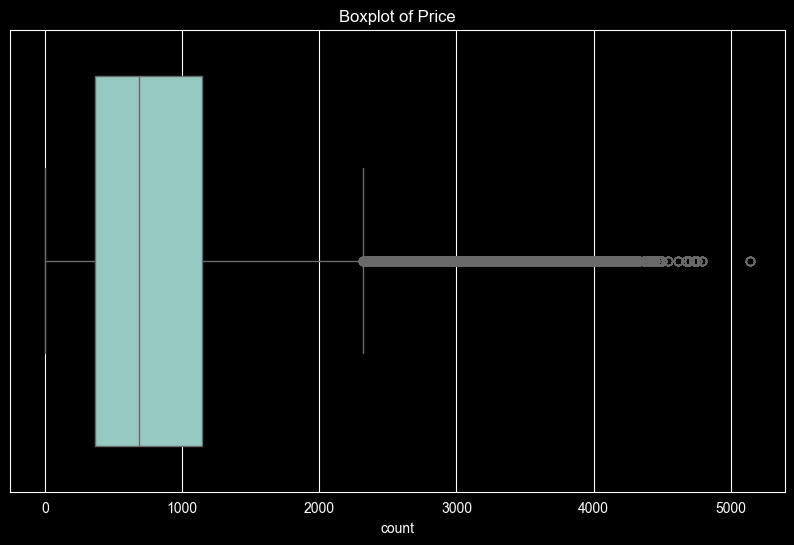

In [30]:
# check for outliers in price column using boxplot
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x=merged_data['count'])
plt.title('Boxplot of Price')
plt.show()

those outliers are caused by events with special food offers, so we will keep them as is.

In [31]:
# unique meal values count
print("Unique meal values count:")
print(len(merged_data['meal'].unique()))

Unique meal values count:
21546


## Export Cleaned Data

In [32]:
merged_data.shape

(3391182, 9)

In [33]:
# export merged_data to cleaned_data.pkl
merged_data.to_csv('../data/processed/cleaned_data.csv')